In [1]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import benford_torch as ref

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
torch.set_default_device(device)

path_clean     = "../frames/test/clean/00005157.jpg"
path_corrupted = "../frames/test/corrupted/level2_medio/00004691.jpg"

image_clean     = cv2.imread(path_clean,     cv2.IMREAD_GRAYSCALE)
image_corrupted = cv2.imread(path_corrupted, cv2.IMREAD_GRAYSCALE)

image_clean_t     = ref.crop_image(torch.tensor(image_clean,     dtype=torch.float, device=device), ref.BLOCK_SIZE)
image_corrupted_t = ref.crop_image(torch.tensor(image_corrupted, dtype=torch.float, device=device), ref.BLOCK_SIZE)


Using cuda device


In [2]:
Q_80  = ref.get_quantization_matrix(80)
Q_95  = ref.get_quantization_matrix(95)

bases = [10, 20, 40, 60]

coefs_clean     = ref.get_all_coefs(image_clean_t,     [Q_80, Q_95])
coefs_corrupted = ref.get_all_coefs(image_corrupted_t, [Q_80, Q_95])

digits_clean     = ref.get_all_digits(coefs_clean,     bases)
digits_corrupted = ref.get_all_digits(coefs_corrupted, bases)


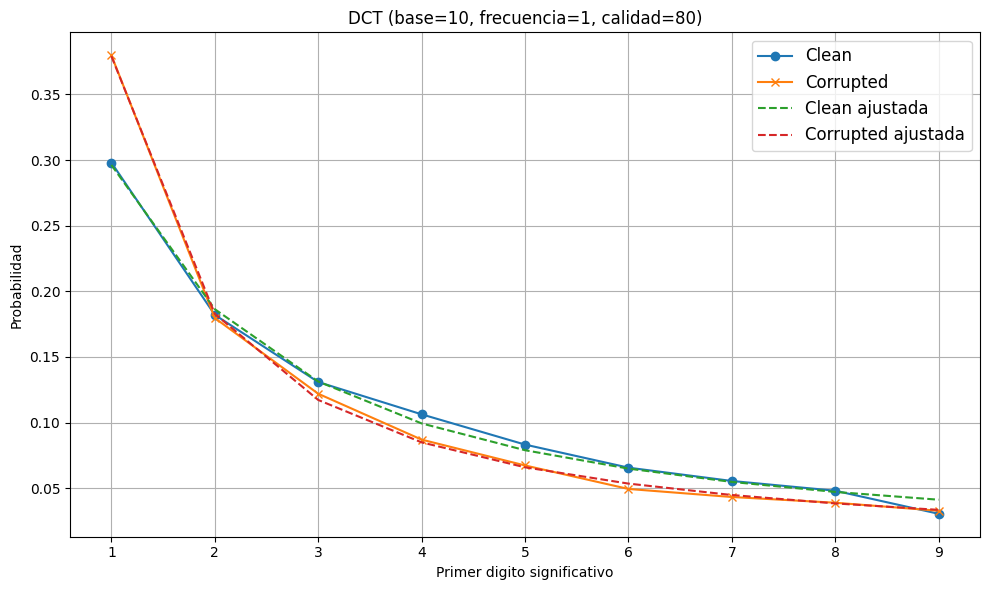

In [3]:
# DCT: base=10, frequency=1, quality=80
p_clean_10_1_80     = ref.get_pdf_est(digits_clean,     b=0, n=1, delta=0, base=10)
p_corrupted_10_1_80 = ref.get_pdf_est(digits_corrupted, b=0, n=1, delta=0, base=10)
p_fit_clean_10_1_80     = ref.get_pdf_fit(p_clean_10_1_80)
p_fit_corrupted_10_1_80 = ref.get_pdf_fit(p_corrupted_10_1_80)

plt.figure(figsize=(10, 6))
plt.plot(list(p_clean_10_1_80.keys()),         list(p_clean_10_1_80.values()),         marker="o", label="Clean")
plt.plot(list(p_corrupted_10_1_80.keys()),     list(p_corrupted_10_1_80.values()),     marker="x", label="Corrupted")
plt.plot(list(p_fit_clean_10_1_80.keys()),     list(p_fit_clean_10_1_80.values()),     linestyle="--", label="Clean ajustada")
plt.plot(list(p_fit_corrupted_10_1_80.keys()), list(p_fit_corrupted_10_1_80.values()), linestyle="--", label="Corrupted ajustada")
plt.xlabel("Primer digito significativo")
plt.ylabel("Probabilidad")
plt.title("DCT (base=10, frecuencia=1, calidad=80)")
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("benford_dct_base10_freq1_q80.jpg")
plt.show()


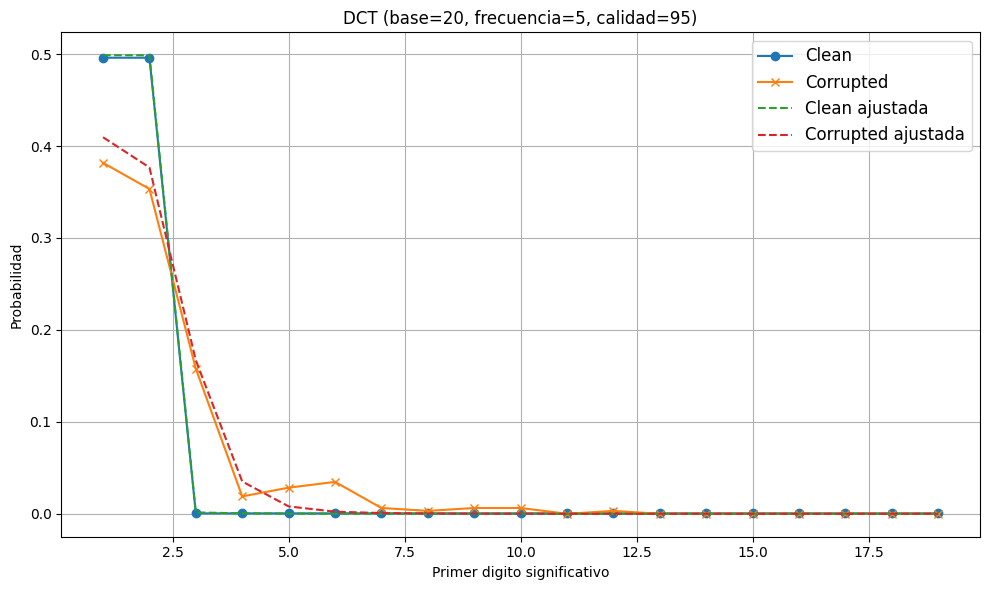

In [4]:
# DCT: base=20, frequency=5, quality=95
p_clean_20_5_95     = ref.get_pdf_est(digits_clean,     b=1, n=5, delta=1, base=20)
p_corrupted_20_5_95 = ref.get_pdf_est(digits_corrupted, b=1, n=5, delta=1, base=20)
p_fit_clean_20_5_95     = ref.get_pdf_fit(p_clean_20_5_95)
p_fit_corrupted_20_5_95 = ref.get_pdf_fit(p_corrupted_20_5_95)

plt.figure(figsize=(10, 6))
plt.plot(list(p_clean_20_5_95.keys()),         list(p_clean_20_5_95.values()),         marker="o", label="Clean")
plt.plot(list(p_corrupted_20_5_95.keys()),     list(p_corrupted_20_5_95.values()),     marker="x", label="Corrupted")
plt.plot(list(p_fit_clean_20_5_95.keys()),     list(p_fit_clean_20_5_95.values()),     linestyle="--", label="Clean ajustada")
plt.plot(list(p_fit_corrupted_20_5_95.keys()), list(p_fit_corrupted_20_5_95.values()), linestyle="--", label="Corrupted ajustada")
plt.xlabel("Primer digito significativo")
plt.ylabel("Probabilidad")
plt.title("DCT (base=20, frecuencia=5, calidad=95)")
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("benford_dct_base20_freq5_q95.jpg")
plt.show()
